<a href="https://colab.research.google.com/github/sharmalalbabu266-ctrl/BSC_research_proposal/blob/main/Final%20Sharemarket%20analysis%20Result2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import shapiro
from scipy.stats import jarque_bera
from scipy.stats import anderson
from scipy.stats import kstest
from scipy.stats import skew
from scipy.stats import kurtosis

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('ggplot')

In [4]:
df = pd.read_csv("/nepse_data.csv")

In [5]:
print(df.head())

print()

print(df.columns)

  Symbol        Date     Open     High      Low    Close Percent Change  \
0  NEPSE  2026-07-17  2599.43  2677.64  2598.24  2677.54         3.06 %   
1  NEPSE  2026-07-16  2605.26  2606.89  2581.09  2597.80         0.28 %   
2  NEPSE  2026-07-15  2577.24  2601.99  2576.61  2590.29         0.54 %   
3  NEPSE  2026-07-14  2569.20  2584.30  2546.69  2576.29         0.23 %   
4  NEPSE  2026-07-13  2599.66  2607.04  2566.27  2570.18        -1.17 %   

             Volume Turn Over  
0  4,575,094,723.51         -  
1  4,562,950,700.46         -  
2  4,170,398,049.64         -  
3  8,417,570,425.82         -  
4  7,468,416,116.81         -  

Index(['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change',
       'Volume', 'Turn Over'],
      dtype='object')


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

df = df.sort_values('Date')

df = df.dropna()

df.reset_index(drop=True, inplace=True)

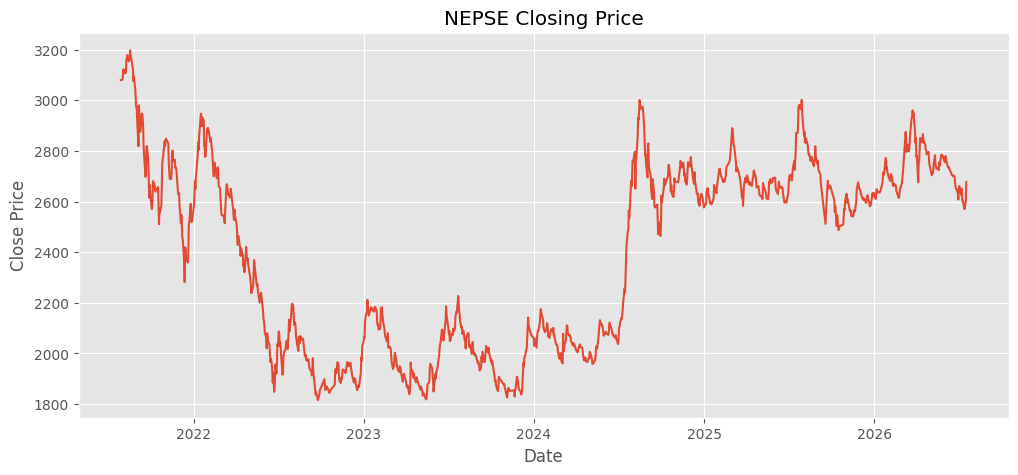

In [7]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Close'])

plt.title("NEPSE Closing Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.grid(True)

plt.show()

In [9]:
df['LogPrice'] = np.log(df['Close'])

In [10]:
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))

df = df.dropna()

df.head()

,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turn Over,LogPrice,LogReturn
1,NEPSE,2021-08-01,3088.45,3099.13,3075.54,3081.07,0.03 %,"12,103,871,861.91",-,8.033032,0.000406
2,NEPSE,2021-08-02,3087.91,3101.30,3079.04,3085.07,0.13 %,"10,983,682,606.43",-,8.034330,0.001297
3,NEPSE,2021-08-03,3094.24,3111.16,3091.92,3111.09,0.00 %,"11,529,217,774.66",-,8.042728,0.008399
4,NEPSE,2021-08-04,3126.99,3140.38,3120.78,3123.15,0.32 %,"15,595,794,271.04",-,8.046597,0.003869
5,NEPSE,2021-08-05,3130.54,3138.61,3101.79,3107.45,-0.50 %,"14,316,249,964.69",-,8.041558,-0.005040


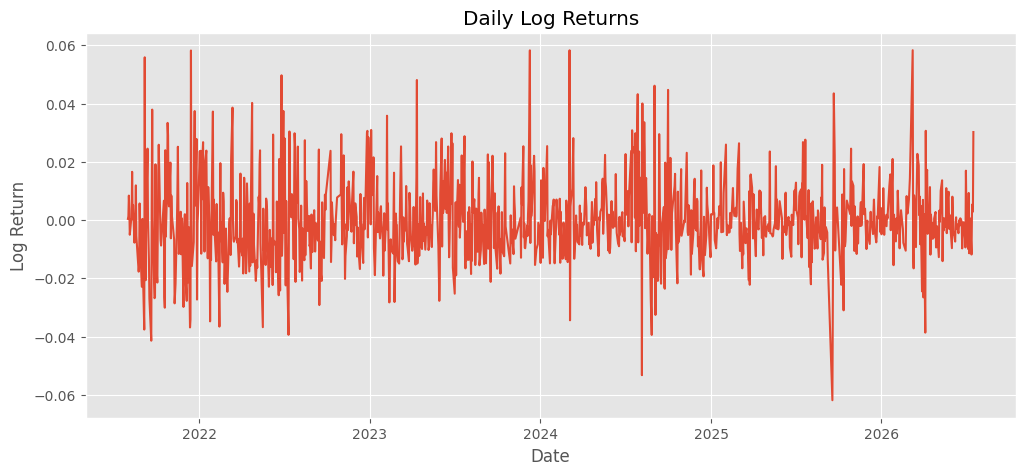

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['LogReturn'])

plt.title("Daily Log Returns")

plt.xlabel("Date")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [12]:
print(df['LogReturn'].describe())

count    1150.000000
mean       -0.000122
std         0.013725
min        -0.061877
25%        -0.007965
50%        -0.001129
75%         0.006347
max         0.058335
Name: LogReturn, dtype: float64


In [13]:
mu = df['LogReturn'].mean()

print("Drift (μ) =", mu)

Drift (μ) = -0.00012171538363655394


In [14]:
sigma = df['LogReturn'].std()

print("Volatility (σ) =", sigma)

Volatility (σ) = 0.01372532515863823


In [15]:
print("========== GBM Parameters ==========")

print(f"Drift (μ): {mu:.6f}")

print(f"Volatility (σ): {sigma:.6f}")

========== GBM Parameters ==========
Drift (μ): -0.000122
Volatility (σ): 0.013725


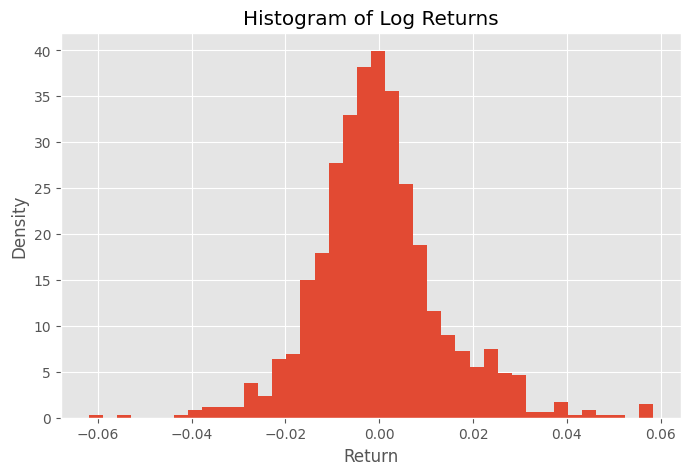

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['LogReturn'],
         bins=40,
         density=True)

plt.title("Histogram of Log Returns")

plt.xlabel("Return")

plt.ylabel("Density")

plt.show()

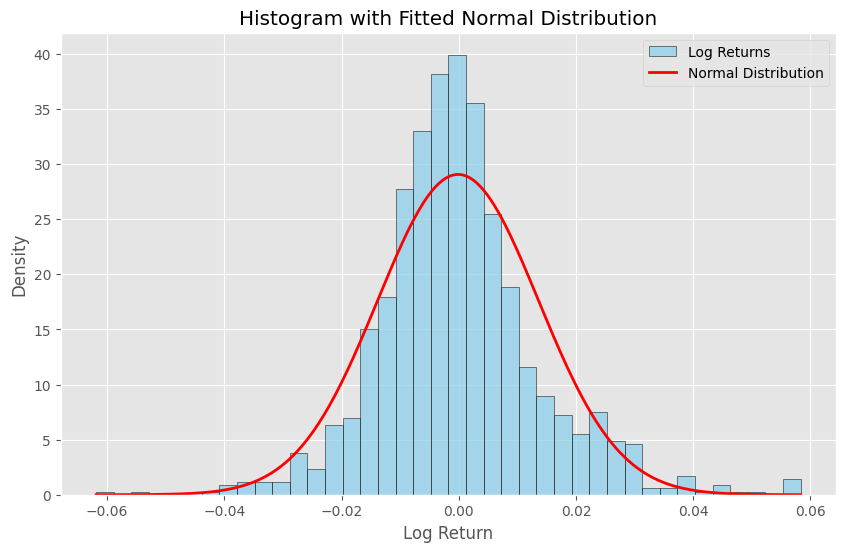

In [17]:
plt.figure(figsize=(10,6))

# Histogram
plt.hist(df['LogReturn'],
         bins=40,
         density=True,
         alpha=0.7,
         color='skyblue',
         edgecolor='black',
         label='Log Returns')

# Fit Normal Distribution
mu_fit = df['LogReturn'].mean()
sigma_fit = df['LogReturn'].std()

x = np.linspace(df['LogReturn'].min(),
                df['LogReturn'].max(),
                500)

plt.plot(x,
         norm.pdf(x, mu_fit, sigma_fit),
         'r',
         linewidth=2,
         label='Normal Distribution')

plt.title("Histogram with Fitted Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

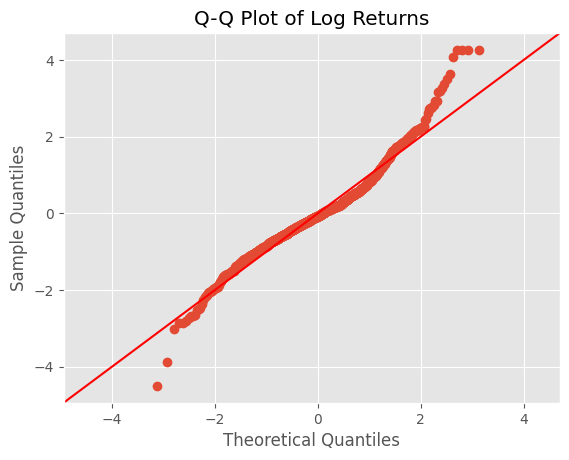

In [18]:
plt.figure(figsize=(6,6))

sm.qqplot(df['LogReturn'],
          line='45',
          fit=True)

plt.title("Q-Q Plot of Log Returns")
plt.grid(True)
plt.show()

In [19]:
stat, p = shapiro(df['LogReturn'])

print("Shapiro-Wilk Test")
print("Statistic =", stat)
print("p-value =", p)

if p > 0.05:
    print("Result: Returns are approximately normal.")
else:
    print("Result: Reject normality.")

Shapiro-Wilk Test
Statistic = 0.9635654989164364
p-value = 2.262623080357679e-16
Result: Reject normality.


In [20]:
jb_stat, jb_p = jarque_bera(df['LogReturn'])

print("Jarque-Bera Test")
print("Statistic =", jb_stat)
print("p-value =", jb_p)

if jb_p > 0.05:
    print("Result: Returns are approximately normal.")
else:
    print("Result: Reject normality.")

Jarque-Bera Test
Statistic = 291.408185376794
p-value = 5.2664328943025406e-64
Result: Reject normality.


In [21]:
result = anderson(df['LogReturn'])

print("Anderson-Darling Test")
print("Statistic =", result.statistic)

print("\nCritical Values")
for cv, sl in zip(result.critical_values,
                  result.significance_level):
    print(f"{sl}% : {cv}")

if result.statistic < result.critical_values[2]:
    print("\nResult: Returns are approximately normal (5% level).")
else:
    print("\nResult: Reject normality (5% level).")

Anderson-Darling Test
Statistic = 11.53822119917345

Critical Values
15.0% : 0.574
10.0% : 0.654
5.0% : 0.784
2.5% : 0.915
1.0% : 1.088

Result: Reject normality (5% level).


In [22]:
ks_stat, ks_p = kstest(
    df['LogReturn'],
    'norm',
    args=(mu_fit, sigma_fit)
)

print("Kolmogorov-Smirnov Test")
print("Statistic =", ks_stat)
print("p-value =", ks_p)

if ks_p > 0.05:
    print("Result: Returns are approximately normal.")
else:
    print("Result: Reject normality.")

Kolmogorov-Smirnov Test
Statistic = 0.08170958440641884
p-value = 3.978578060208081e-07
Result: Reject normality.


In [23]:
sk = skew(df['LogReturn'])

print("Skewness =", sk)

if sk > 0:
    print("Distribution is positively skewed.")
elif sk < 0:
    print("Distribution is negatively skewed.")
else:
    print("Distribution is symmetric.")

Skewness = 0.5173136735888046
Distribution is positively skewed.


In [24]:
kt = kurtosis(df['LogReturn'], fisher=False)

print("Kurtosis =", kt)

if kt > 3:
    print("Leptokurtic (fat tails).")
elif kt < 3:
    print("Platykurtic (thin tails).")
else:
    print("Mesokurtic (normal distribution).")

Kurtosis = 5.238550509163213
Leptokurtic (fat tails).


In [25]:
summary = pd.DataFrame({
    'Statistic': [
        'Mean (μ)',
        'Volatility (σ)',
        'Skewness',
        'Kurtosis',
        'Shapiro p',
        'Jarque-Bera p',
        'KS p'
    ],
    'Value': [
        mu_fit,
        sigma_fit,
        sk,
        kt,
        p,
        jb_p,
        ks_p
    ]
})

print(summary)

        Statistic         Value
0        Mean (μ) -1.217154e-04
1  Volatility (σ)  1.372533e-02
2        Skewness  5.173137e-01
3        Kurtosis  5.238551e+00
4       Shapiro p  2.262623e-16
5   Jarque-Bera p  5.266433e-64
6            KS p  3.978578e-07


In [26]:
# Initial stock price
S0 = df['Close'].iloc[0]

# Number of observations
N = len(df)

# Time step (1 trading day)
dt = 1

print("Initial Price:", S0)
print("Number of Days:", N)
print("Drift (μ):", mu)
print("Volatility (σ):", sigma)

Initial Price: 3081.07
Number of Days: 1150
Drift (μ): -0.00012171538363655394
Volatility (σ): 0.01372532515863823


In [27]:
np.random.seed(42)

# Random shocks
Z = np.random.normal(0, 1, N)

# Wiener process increments
dW = np.sqrt(dt) * Z

# Wiener process
W = np.cumsum(dW)

In [28]:
t = np.arange(N)

GBM = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

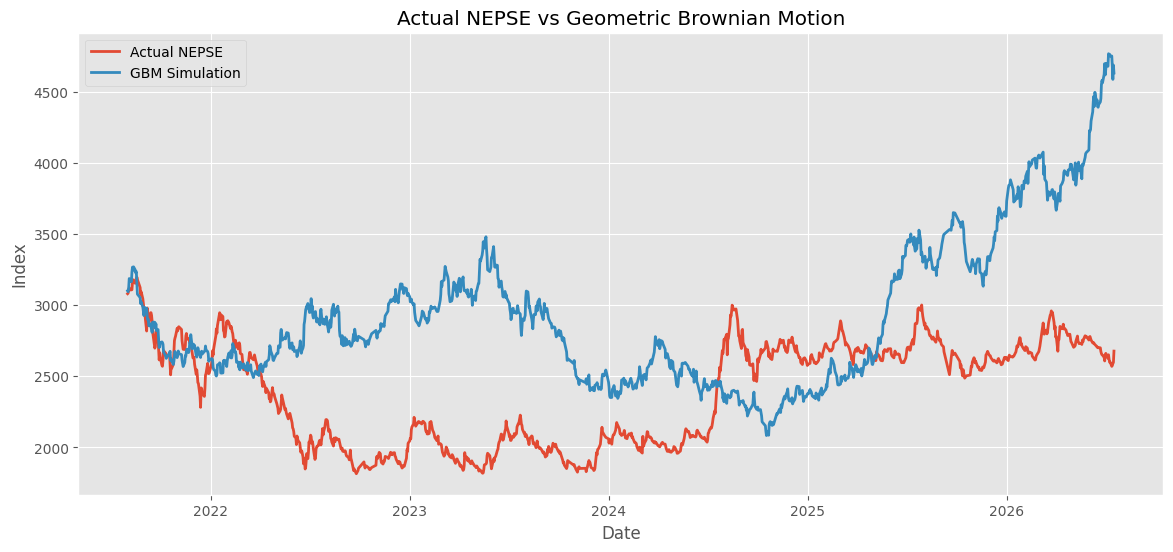

In [29]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'],
         df['Close'],
         label='Actual NEPSE',
         linewidth=2)

plt.plot(df['Date'],
         GBM,
         label='GBM Simulation',
         linewidth=2)

plt.title("Actual NEPSE vs Geometric Brownian Motion")

plt.xlabel("Date")

plt.ylabel("Index")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

MAE = mean_absolute_error(df['Close'], GBM)

RMSE = np.sqrt(mean_squared_error(df['Close'], GBM))

print("MAE =", MAE)

print("RMSE =", RMSE)

MAE = 652.3564561052797
RMSE = 785.011592113804


In [31]:
MAPE = np.mean(
    np.abs((df['Close'] - GBM) / df['Close'])
) * 100

print("MAPE =", MAPE, "%")

MAPE = 28.974309438872158 %


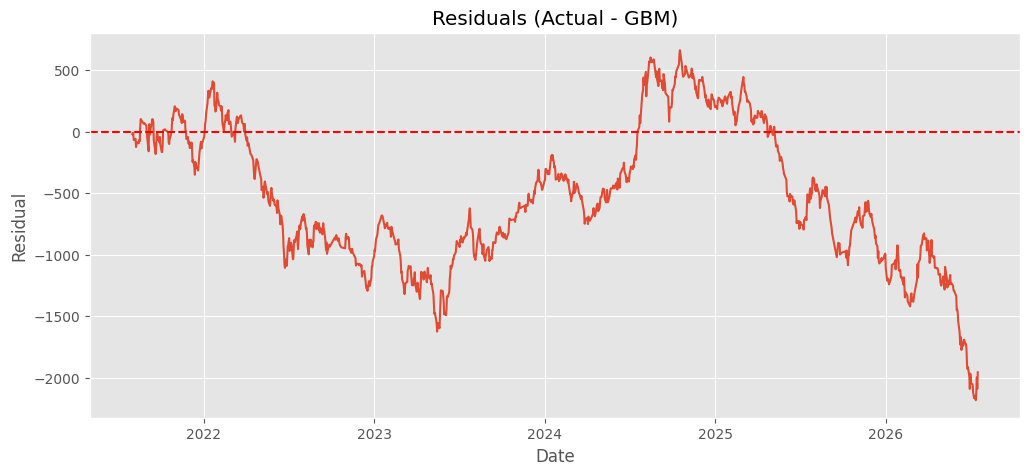

In [32]:
Residual = df['Close'] - GBM

plt.figure(figsize=(12,5))

plt.plot(df['Date'],
         Residual)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.title("Residuals (Actual - GBM)")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

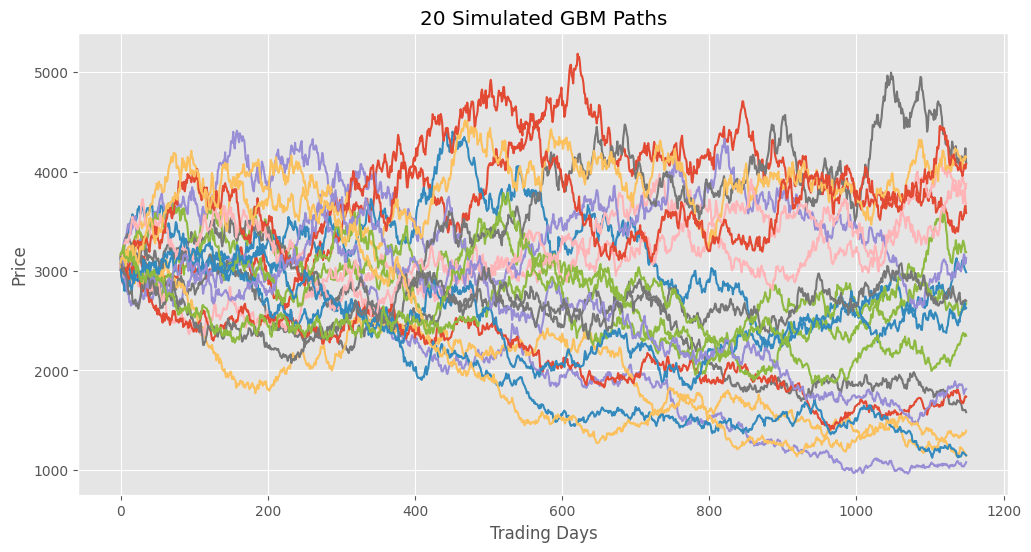

In [33]:
plt.figure(figsize=(12,6))

num_paths = 20

for i in range(num_paths):

    Z = np.random.normal(size=N)

    W = np.cumsum(np.sqrt(dt) * Z)

    path = S0 * np.exp(
        (mu - 0.5 * sigma**2) * t +
        sigma * W
    )

    plt.plot(path)

plt.title("20 Simulated GBM Paths")

plt.xlabel("Trading Days")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [34]:
print("Actual Final Price")

print(df['Close'].iloc[-1])

print()

print("GBM Final Price")

print(GBM[-1])

Actual Final Price
2677.54

GBM Final Price
4633.9366894694795


In [35]:
# Logarithmic prices
log_price = df['LogPrice'].values

In [36]:
max_lag = 100      # You can change to 50, 100, or 200

lags = np.arange(1, max_lag + 1)

msd = []

for lag in lags:

    displacement = log_price[lag:] - log_price[:-lag]

    msd.append(np.mean(displacement**2))

msd = np.array(msd)

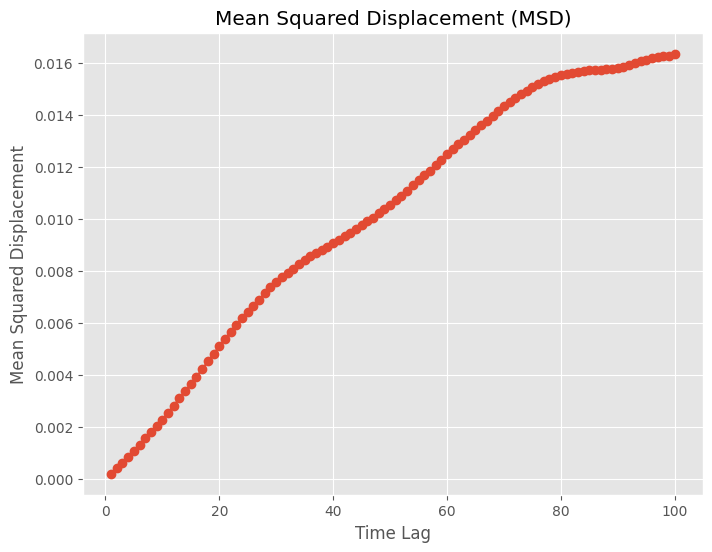

In [37]:
plt.figure(figsize=(8,6))

plt.plot(lags,
         msd,
         'o-')

plt.xlabel("Time Lag")

plt.ylabel("Mean Squared Displacement")

plt.title("Mean Squared Displacement (MSD)")

plt.grid(True)

plt.show()

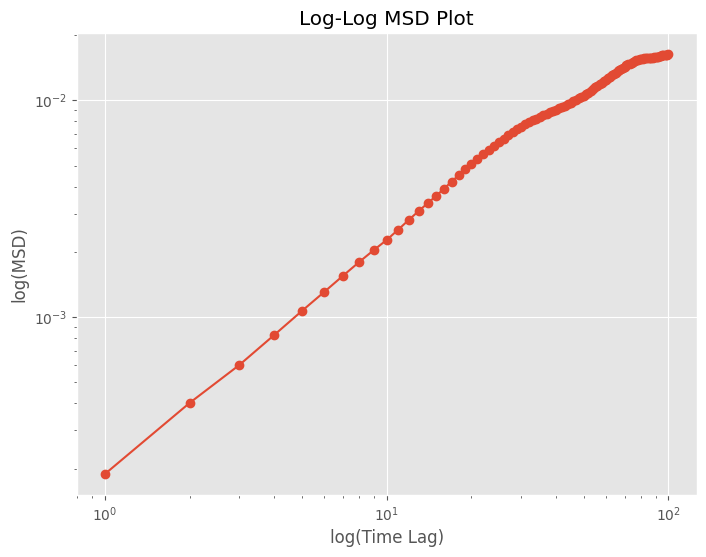

In [38]:
plt.figure(figsize=(8,6))

plt.loglog(lags,
           msd,
           'o-')

plt.xlabel("log(Time Lag)")

plt.ylabel("log(MSD)")

plt.title("Log-Log MSD Plot")

plt.grid(True)

plt.show()

In [39]:
coeff = np.polyfit(np.log(lags),
                   np.log(msd),
                   1)

alpha = coeff[0]

print("Diffusion Exponent (α) =", alpha)

Diffusion Exponent (α) = 0.9349863485034292


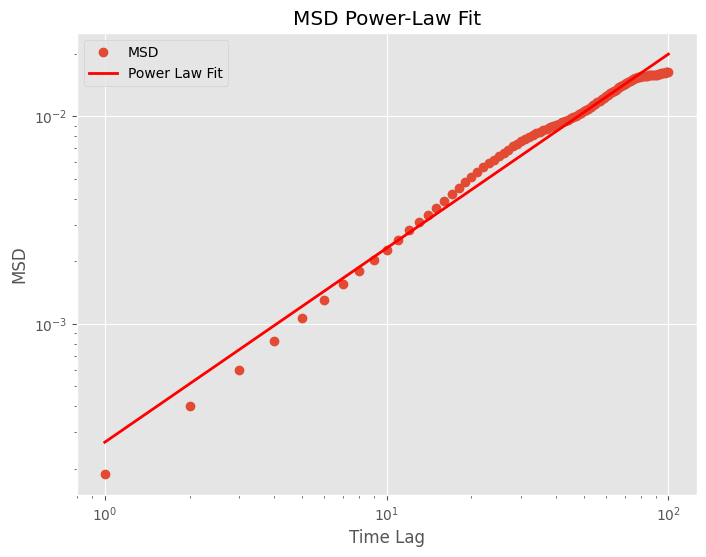

In [40]:
fit = np.exp(coeff[1]) * lags**alpha

plt.figure(figsize=(8,6))

plt.loglog(lags,
           msd,
           'o',
           label='MSD')

plt.loglog(lags,
           fit,
           'r',
           linewidth=2,
           label='Power Law Fit')

plt.xlabel("Time Lag")

plt.ylabel("MSD")

plt.title("MSD Power-Law Fit")

plt.legend()

plt.grid(True)

plt.show()

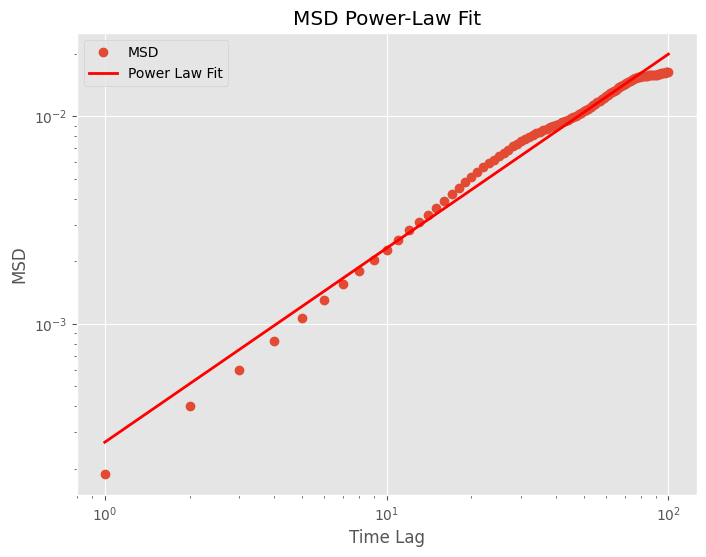

In [41]:
fit = np.exp(coeff[1]) * lags**alpha

plt.figure(figsize=(8,6))

plt.loglog(lags,
           msd,
           'o',
           label='MSD')

plt.loglog(lags,
           fit,
           'r',
           linewidth=2,
           label='Power Law Fit')

plt.xlabel("Time Lag")

plt.ylabel("MSD")

plt.title("MSD Power-Law Fit")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
print("Diffusion Exponent α =", alpha)

if abs(alpha - 1) < 0.1:
    print("Normal Diffusion (Brownian Motion)")
elif alpha < 1:
    print("Sub-Diffusion")
else:
    print("Super-Diffusion")

Diffusion Exponent α = 0.9349863485034292
Normal Diffusion (Brownian Motion)


In [43]:
# Fit first 20 lags
coef = np.polyfit(lags[:20],
                  msd[:20],
                  1)

D = coef[0] / 2

print("Diffusion Coefficient (D) =", D)

Diffusion Coefficient (D) = 0.00012957939385434112


In [44]:
physics = pd.DataFrame({

    "Quantity":[
        "Diffusion Exponent",
        "Diffusion Coefficient"
    ],

    "Value":[
        alpha,
        D
    ]

})

print(physics)

                Quantity     Value
0     Diffusion Exponent  0.934986
1  Diffusion Coefficient  0.000130


In [45]:
# Absolute log returns
abs_returns = np.abs(df['LogReturn'])

print(abs_returns.head())

1    0.000406
2    0.001297
3    0.008399
4    0.003869
5    0.005040
Name: LogReturn, dtype: float64


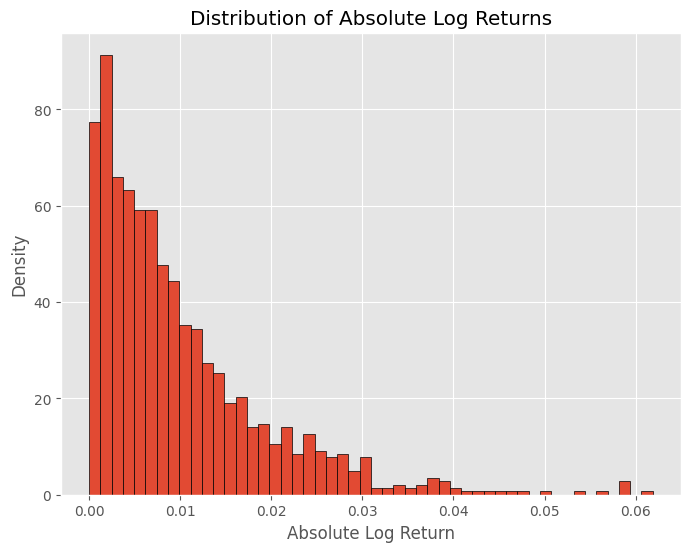

In [46]:
plt.figure(figsize=(8,6))

plt.hist(abs_returns,
         bins=50,
         density=True,
         edgecolor='black')

plt.xlabel("Absolute Log Return")
plt.ylabel("Density")
plt.title("Distribution of Absolute Log Returns")

plt.grid(True)
plt.show()

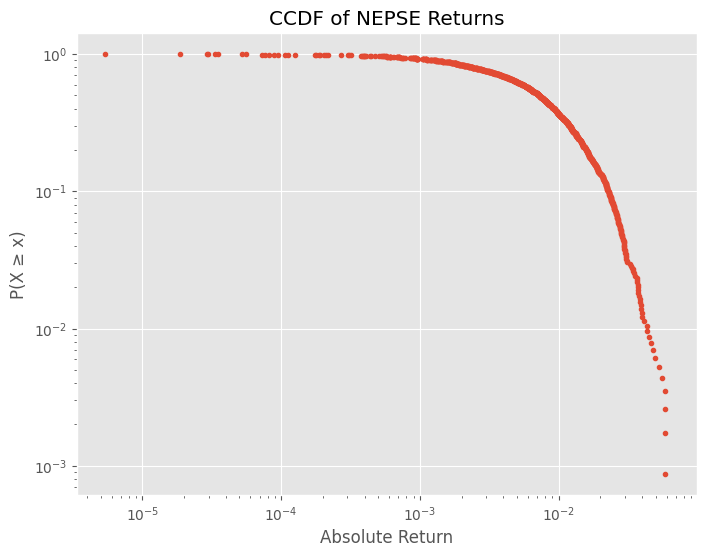

In [47]:
# Sort returns
sorted_returns = np.sort(abs_returns)

# Survival probability (CCDF)
ccdf = 1 - np.arange(1, len(sorted_returns)+1) / len(sorted_returns)

plt.figure(figsize=(8,6))

plt.loglog(sorted_returns,
           ccdf,
           'o',
           markersize=3)

plt.xlabel("Absolute Return")

plt.ylabel("P(X ≥ x)")

plt.title("CCDF of NEPSE Returns")

plt.grid(True)

plt.show()

In [48]:
threshold = np.percentile(abs_returns, 90)

tail = abs_returns[abs_returns >= threshold]

print("Tail observations:", len(tail))

Tail observations: 115


In [49]:
xmin = tail.min()

alpha_power = 1 + len(tail) / np.sum(np.log(tail / xmin))

print("Estimated Power-law Exponent =", alpha_power)

Estimated Power-law Exponent = 4.5068448628809


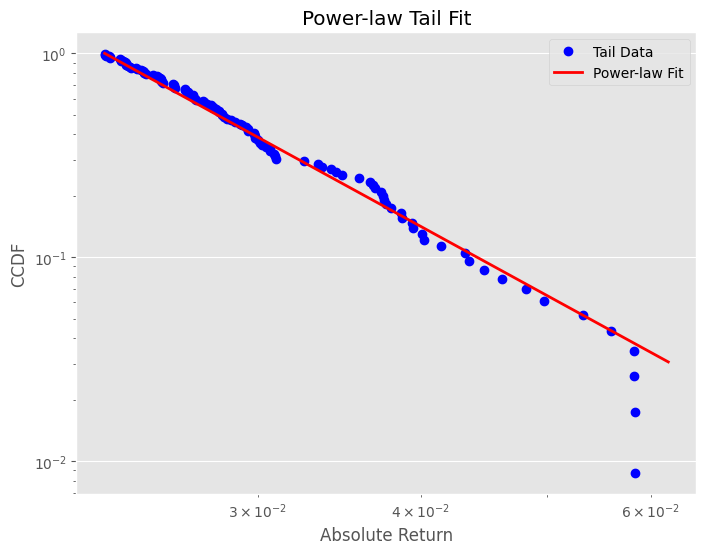

In [50]:
sorted_tail = np.sort(tail)

ccdf_tail = 1 - np.arange(1, len(sorted_tail)+1)/len(sorted_tail)

plt.figure(figsize=(8,6))

plt.loglog(sorted_tail,
           ccdf_tail,
           'bo',
           label='Tail Data')

fit = (sorted_tail / xmin)**(-(alpha_power - 1))

plt.loglog(sorted_tail,
           fit,
           'r',
           linewidth=2,
           label='Power-law Fit')

plt.xlabel("Absolute Return")

plt.ylabel("CCDF")

plt.title("Power-law Tail Fit")

plt.legend()

plt.grid(True)

plt.show()

In [51]:
print("Power-law Exponent =", alpha_power)

if alpha_power < 3:
    print("Heavy-tailed distribution.")
else:
    print("Tail is relatively thin.")

Power-law Exponent = 4.5068448628809
Tail is relatively thin.


In [52]:
power_table = pd.DataFrame({

    "Quantity":[
        "Tail Threshold",
        "Tail Size",
        "Power-law Exponent"
    ],

    "Value":[
        threshold,
        len(tail),
        alpha_power
    ]

})

print(power_table)

             Quantity       Value
0      Tail Threshold    0.022757
1           Tail Size  115.000000
2  Power-law Exponent    4.506845


<Figure size 1000x500 with 0 Axes>

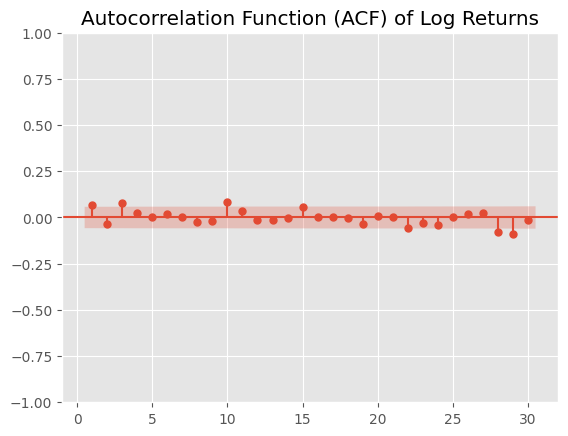

In [53]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(df['LogReturn'],
         lags=30,
         zero=False)

plt.title("Autocorrelation Function (ACF) of Log Returns")

plt.show()

In [54]:
print("Autocorrelation Coefficients")

for lag in range(1,11):

    corr = df['LogReturn'].autocorr(lag=lag)

    print(f"Lag {lag}: {corr:.5f}")

Autocorrelation Coefficients
Lag 1: 0.06678
Lag 2: -0.03800
Lag 3: 0.07669
Lag 4: 0.02452
Lag 5: 0.00024
Lag 6: 0.01778
Lag 7: 0.00230
Lag 8: -0.02353
Lag 9: -0.01899
Lag 10: 0.08682


In [55]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(df['LogReturn'],
                    lags=[10,20],
                    return_df=True)

print(lb)

      lb_stat  lb_pvalue
10  24.337329   0.006754
20  31.403945   0.050079


In [56]:
for lag in [10,20]:

    p = lb.loc[lag,'lb_pvalue']

    print(f"Lag {lag}")

    if p > 0.05:
        print("No significant autocorrelation (Random Walk).")

    else:
        print("Autocorrelation exists.")

Lag 10
Autocorrelation exists.
Lag 20
No significant autocorrelation (Random Walk).


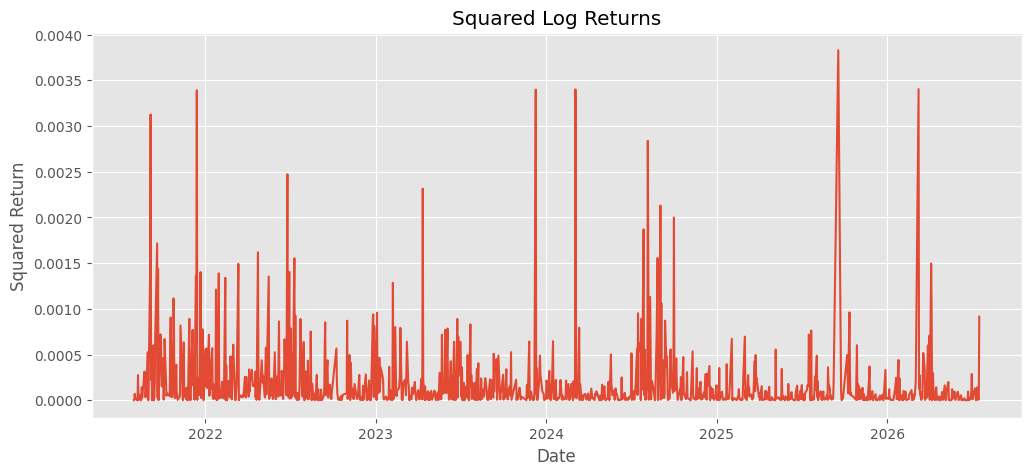

In [57]:
df['SquaredReturn'] = df['LogReturn']**2

plt.figure(figsize=(12,5))

plt.plot(df['Date'],
         df['SquaredReturn'])

plt.title("Squared Log Returns")

plt.xlabel("Date")

plt.ylabel("Squared Return")

plt.grid(True)

plt.show()

<Figure size 1000x500 with 0 Axes>

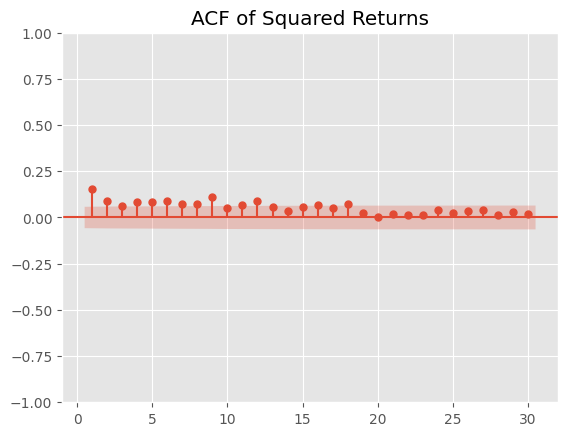

In [58]:
plt.figure(figsize=(10,5))

plot_acf(df['SquaredReturn'],
         lags=30,
         zero=False)

plt.title("ACF of Squared Returns")

plt.show()

In [59]:
lb_sq = acorr_ljungbox(df['SquaredReturn'],
                       lags=[10,20],
                       return_df=True)

print(lb_sq)

       lb_stat     lb_pvalue
10   96.789331  2.388190e-16
20  134.209025  6.299585e-19


In [60]:
for lag in [10,20]:

    p = lb_sq.loc[lag,'lb_pvalue']

    print(f"Lag {lag}")

    if p < 0.05:

        print("Volatility clustering detected.")

    else:

        print("No significant volatility clustering.")

Lag 10
Volatility clustering detected.
Lag 20
Volatility clustering detected.


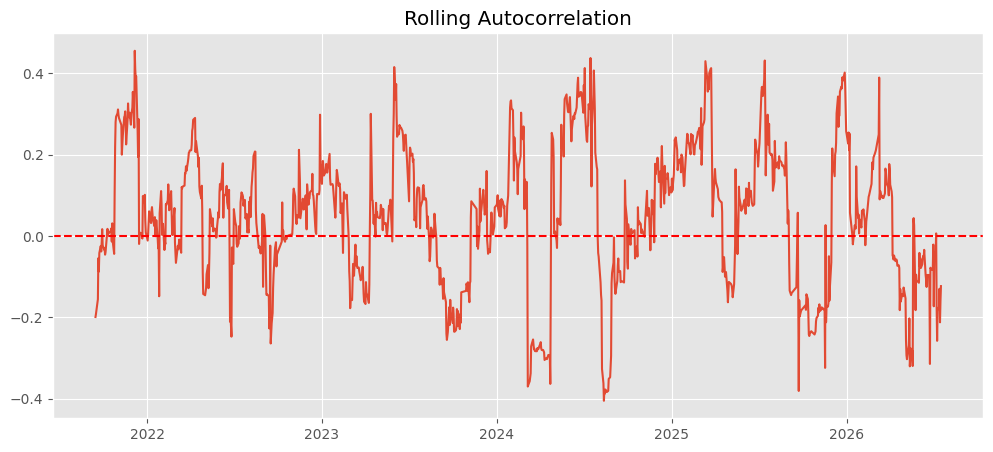

In [61]:
rolling_corr = []

window = 30

for i in range(window, len(df)):

    corr = df['LogReturn'].iloc[i-window:i].autocorr()

    rolling_corr.append(corr)

plt.figure(figsize=(12,5))

plt.plot(df['Date'][window:],
         rolling_corr)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.title("Rolling Autocorrelation")

plt.grid(True)

plt.show()

In [62]:
autocorr_table = pd.DataFrame({

    "Lag":[1,2,3,4,5],

    "Correlation":[

        df['LogReturn'].autocorr(1),

        df['LogReturn'].autocorr(2),

        df['LogReturn'].autocorr(3),

        df['LogReturn'].autocorr(4),

        df['LogReturn'].autocorr(5)

    ]

})

print(autocorr_table)

   Lag  Correlation
0    1     0.066777
1    2    -0.037996
2    3     0.076695
3    4     0.024520
4    5     0.000235


In [63]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 18.5 MB/s eta 0:00:00


In [64]:
from arch import arch_model

In [65]:
returns = df['LogReturn'] * 100

returns = returns.dropna()

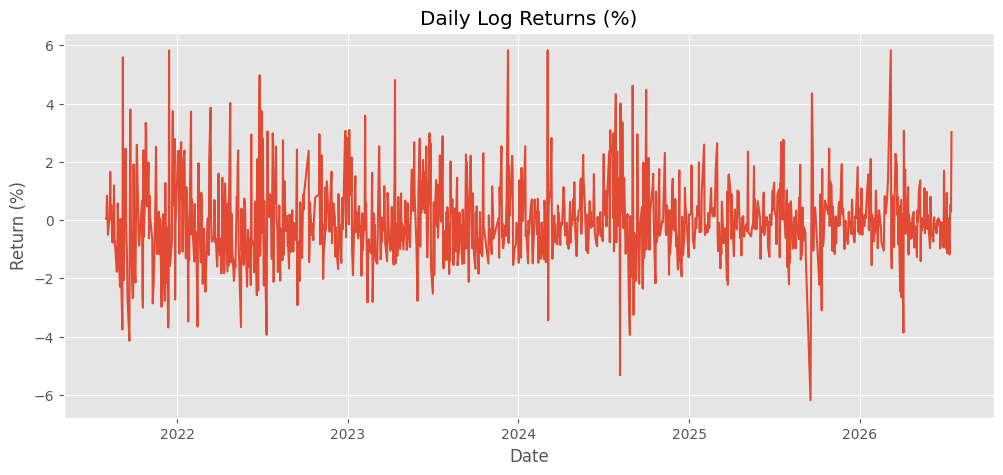

In [67]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], returns)

plt.title("Daily Log Returns (%)")

plt.xlabel("Date")

plt.ylabel("Return (%)")

plt.grid(True)

plt.show()

In [68]:
model = arch_model(
    returns,
    vol='GARCH',
    p=1,
    q=1,
    mean='Constant'
)

result = model.fit(disp='off')

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:              LogReturn   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1939.93
Distribution:                  Normal   AIC:                           3887.86
Method:            Maximum Likelihood   BIC:                           3908.05
                                        No. Observations:                 1150
Date:                Fri, Jul 24 2026   Df Residuals:                     1149
Time:                        14:47:51   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.6925e-03  3.801e-02  4.453e-02      0.964 

In [69]:
omega = result.params['omega']
alpha = result.params['alpha[1]']
beta = result.params['beta[1]']

print("Omega =", omega)
print("Alpha =", alpha)
print("Beta =", beta)

print("Alpha + Beta =", alpha + beta)

Omega = 0.13632289850208598
Alpha = 0.11693483481608445
Beta = 0.8148152820887696
Alpha + Beta = 0.9317501169048541


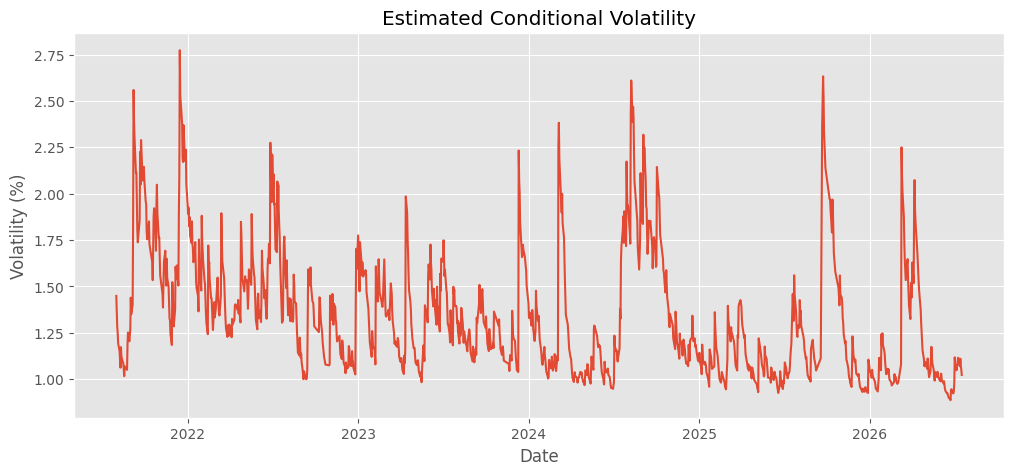

In [72]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'],
         result.conditional_volatility)

plt.title("Estimated Conditional Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility (%)")

plt.grid(True)

plt.show()

In [73]:
forecast = result.forecast(horizon=30)

future_var = forecast.variance.iloc[-1]

future_vol = np.sqrt(future_var)

print(future_vol)

h.01    1.434144
h.02    1.432730
h.03    1.431412
h.04    1.430183
h.05    1.429037
h.06    1.427969
h.07    1.426972
h.08    1.426043
h.09    1.425177
h.10    1.424369
h.11    1.423616
h.12    1.422914
h.13    1.422260
h.14    1.421650
h.15    1.421081
h.16    1.420551
h.17    1.420058
h.18    1.419597
h.19    1.419168
h.20    1.418768
h.21    1.418395
h.22    1.418048
h.23    1.417724
h.24    1.417423
h.25    1.417141
h.26    1.416879
h.27    1.416635
h.28    1.416408
h.29    1.416195
h.30    1.415998
Name: 1150, dtype: float64


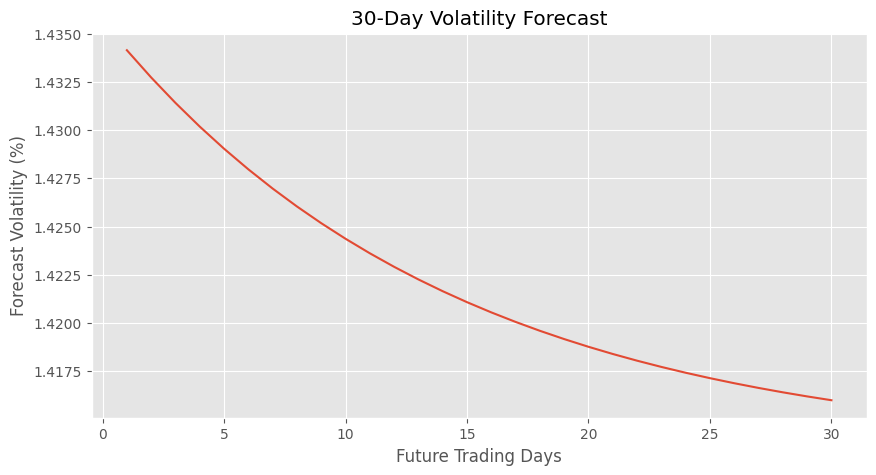

In [74]:
plt.figure(figsize=(10,5))

plt.plot(range(1,31),
         future_vol)

plt.title("30-Day Volatility Forecast")

plt.xlabel("Future Trading Days")

plt.ylabel("Forecast Volatility (%)")

plt.grid(True)

plt.show()

In [75]:
VaR95 = np.percentile(returns,5)

print("95% Historical VaR =", VaR95,"%")

95% Historical VaR = -2.072817612480105 %


In [76]:
VaR99 = np.percentile(returns,1)

print("99% Historical VaR =",VaR99,"%")

99% Historical VaR = -3.4284811875168644 %


In [77]:
ES95 = returns[returns<=VaR95].mean()

print("95% Expected Shortfall =",ES95,"%")

95% Expected Shortfall = -2.816108075626489 %


In [78]:
ES99 = returns[returns<=VaR99].mean()

print("99% Expected Shortfall =",ES99,"%")

99% Expected Shortfall = -4.093083661769104 %


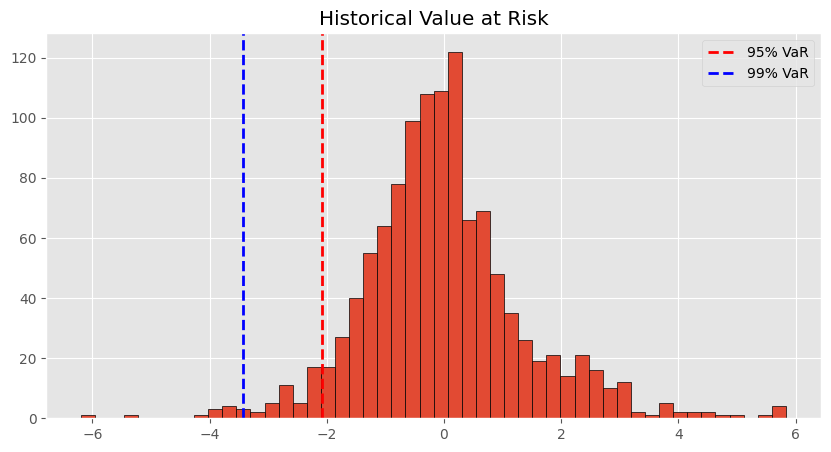

In [79]:
plt.figure(figsize=(10,5))

plt.hist(returns,
         bins=50,
         edgecolor='black')

plt.axvline(VaR95,
            color='red',
            linestyle='--',
            linewidth=2,
            label='95% VaR')

plt.axvline(VaR99,
            color='blue',
            linestyle='--',
            linewidth=2,
            label='99% VaR')

plt.legend()

plt.title("Historical Value at Risk")

plt.grid(True)

plt.show()

In [80]:
risk = pd.DataFrame({

    "Measure":[

        "Omega",

        "Alpha",

        "Beta",

        "Alpha+Beta",

        "95% VaR",

        "99% VaR",

        "95% ES",

        "99% ES"

    ],

    "Value":[

        omega,

        alpha,

        beta,

        alpha+beta,

        VaR95,

        VaR99,

        ES95,

        ES99

    ]

})

print(risk)

      Measure     Value
0       Omega  0.136323
1       Alpha  0.116935
2        Beta  0.814815
3  Alpha+Beta  0.931750
4     95% VaR -2.072818
5     99% VaR -3.428481
6      95% ES -2.816108
7      99% ES -4.093084
